# F1 Race Simulation & Statistical Analysis Engine
Monte Carlo F1 race simulation with an integrated statistical analysis pipeline to prove the validity of the physics and evaluate strategies.

---

## Problem Statement
**Perform a Monte Carlo simulation on the 2024 F1 Grid to evaluate driver performance and pit strategies.**

* **Data:** 20 F1 drivers with base lap times and varied pit strategies (1-stop vs 2-stop).
* **Significance Level:** α = 0.05

### Tasks
1. Generate 1000 sample laps per driver using a Log-Normal distribution.
2. Run 500 Monte Carlo simulations of a 15-lap race, applying pit penalties.
3. Evaluate the random number generator physics using a Chi-Square Goodness-of-Fit test.
4. Determine if pit strategy choice significantly impacts final race time using a One-Way ANOVA test.
5. Evaluate Teammate Battles using a Two-Sample T-Test (assuming unequal variances/Welch).

---

## Import Necessary Libraries

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import itertools
import json
import os


## Step 1: Define Driver Data and Strategies

In [2]:
# Base lap times reflect relative pace
drivers = {
    "Verstappen":  {"base": 90.00},
    "Perez":       {"base": 90.50},
    "Hamilton":    {"base": 90.35},
    "Russell":     {"base": 90.35},
    "Leclerc":     {"base": 90.20},
    "Sainz":       {"base": 90.30},
    "Norris":      {"base": 90.15},
    "Piastri":     {"base": 90.25},
    "Alonso":      {"base": 90.55},
    "Stroll":      {"base": 90.85},
    "Gasly":       {"base": 90.60},
    "Ocon":        {"base": 90.65},
    "Tsunoda":     {"base": 90.60},
    "Ricciardo":   {"base": 90.70},
    "Hulkenberg":  {"base": 90.70},
    "Magnussen":   {"base": 90.75},
    "Albon":       {"base": 90.80},
    "Bottas":      {"base": 90.90},
    "Zhou":        {"base": 90.95},
    "Sargeant":    {"base": 91.00},
}

PIT_PENALTY = 2.5
NUM_LAPS = 15
SIM_RUNS = 500

# Pit strategies (array of [lap, tire_compound])
strategies = {
    "Verstappen":  [[0, "M"], [8, "H"]],
    "Perez":       [[0, "M"], [8, "H"]],
    "Hamilton":    [[0, "S"], [5, "M"], [11, "S"]],
    "Russell":     [[0, "M"], [9, "H"]],
    "Leclerc":     [[0, "S"], [6, "M"]],
    "Sainz":       [[0, "M"], [8, "H"]],
    "Norris":      [[0, "S"], [5, "H"]],
    "Piastri":     [[0, "M"], [7, "H"]],
    "Alonso":      [[0, "H"]],
    "Stroll":      [[0, "M"], [10, "H"]],
    "Gasly":       [[0, "S"], [4, "M"], [10, "S"]],
    "Ocon":        [[0, "M"], [8, "S"]],
    "Tsunoda":     [[0, "S"], [6, "H"]],
    "Ricciardo":   [[0, "M"], [9, "S"]],
    "Hulkenberg":  [[0, "H"]],
    "Magnussen":   [[0, "M"], [7, "H"]],
    "Albon":       [[0, "S"], [5, "M"]],
    "Bottas":      [[0, "M"], [10, "H"]],
    "Zhou":        [[0, "M"], [8, "H"]],
    "Sargeant":    [[0, "H"]],
}


## Step 2: Generate Lap Data (Log-Normal)

In [3]:
lap_data = {}
all_laps_aggregate = []

for name in drivers:
    mu_base = drivers[name]["base"]
    # Generate variance to simulate driver consistency
    sigma_base = 0.8 + np.random.rand() * 0.5

    # Log-Normal distribution mathematics
    var = sigma_base**2
    phi = np.sqrt(var + mu_base**2)
    mu_log = np.log(mu_base**2 / phi)
    sigma_log = np.sqrt(np.log(phi**2 / mu_base**2))

    # Generate 1000 sample laps
    laps = np.random.lognormal(mu_log, sigma_log, 1000)
    laps = np.clip(laps, 80, None) # strict lower bound

    lap_data[name] = laps
    all_laps_aggregate.extend(laps)
    drivers[name]["mu"] = np.mean(laps)
    drivers[name]["sigma"] = np.std(laps)

print("Lap data successfully generated using Log-Normal distributions.")


Lap data successfully generated using Log-Normal distributions.


## Step 3: Perform Monte Carlo Race Simulation

In [4]:
mc_race_times = {name: [] for name in drivers}
results_pos = {name: [] for name in drivers}

for _ in range(SIM_RUNS):
    race_times = {}
    for name in drivers:
        mu = drivers[name]["mu"]
        sigma = drivers[name]["sigma"]

        # Sum random samples from Normal distribution for the race duration
        total = sum(np.random.normal(mu, sigma, NUM_LAPS))

        # Add pit stop time penalty
        total += (len(strategies[name]) - 1) * PIT_PENALTY

        race_times[name] = total
        mc_race_times[name].append(total)

    # Calculate finishing positions for this run
    sorted_names = sorted(race_times, key=race_times.get)
    for pos, name in enumerate(sorted_names):
        results_pos[name].append(pos + 1)

print(f"Monte Carlo Simulation completed: {SIM_RUNS} races simulated.")


Monte Carlo Simulation completed: 500 races simulated.


## Step 4: Podium Contender Benchmark (1-Sample T-Test)

In [5]:
print("--- 1-Sample T-Test: Podium Contender Benchmark ---")
all_avg_times = {name: np.mean(mc_race_times[name]) for name in drivers}
sorted_by_pace = sorted(all_avg_times, key=all_avg_times.get)
top_5_names = sorted_by_pace[:5]

top_5_times = []
for name in top_5_names:
    top_5_times.extend(mc_race_times[name])
elite_benchmark = np.mean(top_5_times)
print(f"Elite Benchmark Time: {elite_benchmark:.2f}s\n")

driver_vs_field = {}
alpha = 0.05
for name, times in mc_race_times.items():
    t_stat, p_val = stats.ttest_1samp(times, elite_benchmark)
    significant = bool(p_val < alpha)

    if name in top_5_names:
        status = "Elite Benchmark"
    elif t_stat > 0 and significant:
        status = "Slower than Elite"
    else:
        status = "Podium Contender"

    driver_vs_field[name] = {
        "t_stat": float(t_stat),
        "p_value": float(p_val),
        "significant": significant,
        "status": status
    }

    # Print a few examples
    if name in ["Alonso", "Hulkenberg", "Ricciardo"]:
        print(f"Driver: {name}")
        print(f"t-Statistic: {t_stat:.2f}, p-Value: {p_val:.4e}")
        if p_val < alpha:
            print(f"Conclusion: Reject Null Hypothesis. Status: {status}\n")
        else:
            print(f"Conclusion: Fail to Reject Null Hypothesis. Status: {status}\n")


--- 1-Sample T-Test: Podium Contender Benchmark ---
Elite Benchmark Time: 1355.27s

Driver: Alonso
t-Statistic: 15.72, p-Value: 1.5388e-45
Conclusion: Reject Null Hypothesis. Status: Slower than Elite

Driver: Ricciardo
t-Statistic: 39.52, p-Value: 8.6846e-156
Conclusion: Reject Null Hypothesis. Status: Slower than Elite

Driver: Hulkenberg
t-Statistic: 23.91, p-Value: 9.5527e-85
Conclusion: Reject Null Hypothesis. Status: Slower than Elite



## Step 5: Teammate Battles (Two-Sample T-Test)

In [6]:
print("--- 2-Sample T-Test: Teammate Battles ---")
teammates = [
    ("Verstappen", "Perez"), ("Hamilton", "Russell"), ("Leclerc", "Sainz"),
    ("Norris", "Piastri"), ("Alonso", "Stroll"), ("Gasly", "Ocon"),
    ("Tsunoda", "Ricciardo"), ("Hulkenberg", "Magnussen"),
    ("Albon", "Sargeant"), ("Bottas", "Zhou")
]

head_to_head = []
alpha = 0.05
for d1, d2 in teammates:
    # Welch's t-test (equal_var=False)
    t_stat, p_val = stats.ttest_ind(mc_race_times[d1], mc_race_times[d2], equal_var=False)
    significant = bool(p_val < alpha)

    winner = "Tie"
    loser = "Tie"
    if significant:
        winner = d1 if t_stat < 0 else d2
        loser = d2 if t_stat < 0 else d1

    head_to_head.append({
        "driver1": d1,
        "driver2": d2,
        "p_value": float(p_val),
        "winner": winner,
        "loser": loser
    })

    if d1 in ["Hamilton", "Leclerc", "Norris"]:
        print(f"Battle: {d1} vs {d2}")
        print(f"t-Statistic: {t_stat:.2f}, p-Value: {p_val:.4e}")
        if significant:
            print(f"Conclusion: Reject Null Hypothesis. Winner: {winner}\n")
        else:
            print(f"Conclusion: Fail to Reject Null Hypothesis. Statistically equal pace.\n")


--- 2-Sample T-Test: Teammate Battles ---
Battle: Hamilton vs Russell
t-Statistic: 8.96, p-Value: 1.6002e-18
Conclusion: Reject Null Hypothesis. Winner: Russell

Battle: Leclerc vs Sainz
t-Statistic: -2.40, p-Value: 1.6648e-02
Conclusion: Reject Null Hypothesis. Winner: Leclerc

Battle: Norris vs Piastri
t-Statistic: -5.68, p-Value: 1.8318e-08
Conclusion: Reject Null Hypothesis. Winner: Norris



## Step 6: Chi-Square Goodness-of-Fit Test

In [7]:
print("--- Chi-Square Goodness of Fit Test (Sample: Verstappen) ---")
sample_data = lap_data["Verstappen"]
obs, bins = np.histogram(sample_data, bins=10)

mu_v = np.mean(sample_data)
var_v = np.var(sample_data)
s_v = np.sqrt(np.log(var_v / mu_v**2 + 1))
scale_v = mu_v / np.sqrt(var_v / mu_v**2 + 1)

expected_probs = (
    stats.lognorm.cdf(bins[1:], s_v, scale=scale_v)
    - stats.lognorm.cdf(bins[:-1], s_v, scale=scale_v)
)
if expected_probs.sum() > 0:
    expected_probs /= expected_probs.sum()
expected = expected_probs * len(sample_data)
expected = np.where(expected == 0, 1e-10, expected)

chi_stat, chi_p = stats.chisquare(obs, expected)
df = len(obs) - 1
alpha = 0.05
critical_value = stats.chi2.ppf(1 - alpha, df)

chi_square_data = {
    "target": "Sample Engine (VER)",
    "chi_stat": float(chi_stat),
    "p_value": float(chi_p),
    "significant": bool(chi_p < 0.05)
}

print(f"Chi-square statistic: {chi_stat:.2f}")
print(f"Degrees of freedom: {df}")
print(f"Critical value (0.05): {critical_value:.2f}")
print(f"P-value: {chi_p:.4f}")

if chi_stat > critical_value:
    print("Conclusion: Reject the null hypothesis. Observed data does not match expected distribution.")
else:
    print("Conclusion: Fail to reject the null hypothesis. Observed data matches the expected Log-Normal distribution.")


--- Chi-Square Goodness of Fit Test (Sample: Verstappen) ---
Chi-square statistic: 4.46
Degrees of freedom: 9
Critical value (0.05): 16.92
P-value: 0.8786
Conclusion: Fail to reject the null hypothesis. Observed data matches the expected Log-Normal distribution.


## Step 7: Visualize Chi-Square Data

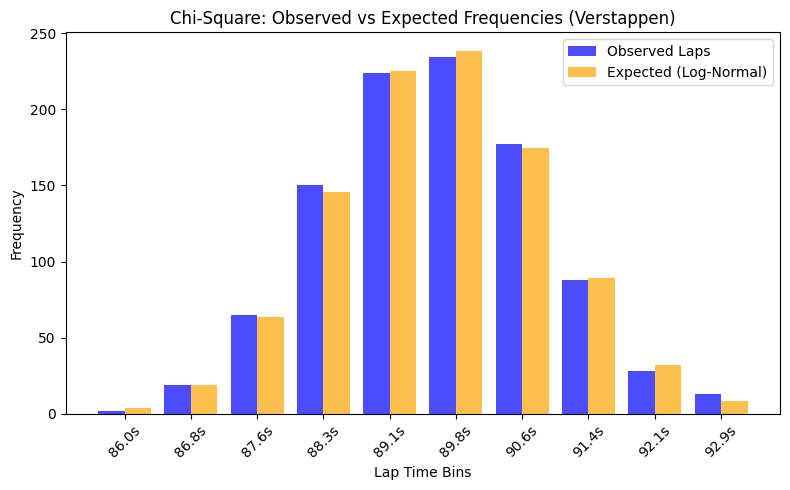

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(obs) + 1), obs, width=0.4, label='Observed Laps', alpha=0.7, color='blue')
plt.bar(np.arange(1, len(obs) + 1) + 0.4, expected, width=0.4, label='Expected (Log-Normal)', alpha=0.7, color='orange')
plt.xlabel('Lap Time Bins')
plt.ylabel('Frequency')
plt.title('Chi-Square: Observed vs Expected Frequencies (Verstappen)')
plt.xticks(np.arange(1, len(obs) + 1) + 0.2, [f"{b:.1f}s" for b in bins[:-1]], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Step 8: Strategy Optimization (One-Way ANOVA)

In [9]:
print("--- One-Way ANOVA: Strategy Optimization ---")
strategy_groups = {}
for name in drivers:
    num_stops = len(strategies[name]) - 1
    if num_stops not in strategy_groups:
        strategy_groups[num_stops] = []
    strategy_groups[num_stops].extend(mc_race_times[name])

anova_data = None
alpha = 0.05
if len(strategy_groups) > 1:
    f_stat, p_val = stats.f_oneway(*strategy_groups.values())
    anova_data = {
        "f_stat": float(f_stat),
        "p_value": float(p_val),
        "significant": bool(p_val < alpha)
    }
    print(f"F-Statistic: {f_stat:.2f}")
    print(f"P-value: {p_val:.4e}")

    if p_val < alpha:
        print("Conclusion: Reject the null hypothesis. Pit strategy significantly impacts final race time.")
    else:
        print("Conclusion: Fail to reject the null hypothesis. Strategies do not significantly differ.")


--- One-Way ANOVA: Strategy Optimization ---
F-Statistic: 28.45
P-value: 4.7833e-13
Conclusion: Reject the null hypothesis. Pit strategy significantly impacts final race time.


## Step 9: Final Race Results & JSON Export

In [10]:
driver_output = {}
print("\n=== FINAL RACE RESULTS (20 DRIVERS) ===")
for name in drivers:
    avg_pos = np.mean(results_pos[name])
    win_prob = results_pos[name].count(1) / SIM_RUNS
    expected_race_time = np.mean(mc_race_times[name])

    driver_output[name] = {
        "mu": float(drivers[name]["mu"]),
        "sigma": float(drivers[name]["sigma"]),
        "avg_position": float(avg_pos),
        "win_probability": float(win_prob),
        "expected_race_time": float(expected_race_time),
        "strategy": strategies[name]
    }
    print(f"{name:12s} Avg Pos: {avg_pos:5.2f} | Win: {win_prob:.2f} | Time: {expected_race_time:.1f}s")

final_payload = {
    "drivers": driver_output,
    "stats": {
        "elite_benchmark": float(elite_benchmark),
        "driver_vs_field": driver_vs_field,
        "head_to_head": head_to_head,
        "chi_square": chi_square_data,
        "anova_strategy": anova_data
    },
    "config": {"num_laps": NUM_LAPS, "sim_runs": SIM_RUNS}
}

os.makedirs("data", exist_ok=True)
with open("data/drivers.json", "w") as f:
    json.dump(final_payload, f, indent=4)

print(f"\nAnalysis complete - payload saved to data/drivers.json")



=== FINAL RACE RESULTS (20 DRIVERS) ===
Verstappen   Avg Pos:  3.21 | Win: 0.44 | Time: 1352.4s
Perez        Avg Pos: 10.20 | Win: 0.00 | Time: 1360.8s
Hamilton     Avg Pos:  8.90 | Win: 0.01 | Time: 1359.8s
Russell      Avg Pos:  6.96 | Win: 0.03 | Time: 1357.8s
Leclerc      Avg Pos:  5.14 | Win: 0.11 | Time: 1355.8s
Sainz        Avg Pos:  5.37 | Win: 0.07 | Time: 1356.4s
Norris       Avg Pos:  4.78 | Win: 0.19 | Time: 1355.1s
Piastri      Avg Pos:  5.55 | Win: 0.07 | Time: 1356.6s
Alonso       Avg Pos:  7.24 | Win: 0.04 | Time: 1358.1s
Stroll       Avg Pos: 14.86 | Win: 0.00 | Time: 1364.8s
Gasly        Avg Pos: 14.07 | Win: 0.00 | Time: 1364.1s
Ocon         Avg Pos: 12.71 | Win: 0.00 | Time: 1363.0s
Tsunoda      Avg Pos: 10.69 | Win: 0.01 | Time: 1361.2s
Ricciardo    Avg Pos: 13.16 | Win: 0.00 | Time: 1363.4s
Hulkenberg   Avg Pos:  9.79 | Win: 0.02 | Time: 1360.4s
Magnussen    Avg Pos: 13.39 | Win: 0.00 | Time: 1363.7s
Albon        Avg Pos: 15.00 | Win: 0.00 | Time: 1365.2s
Bottas 